# Personal Gym Supplements RAG

Same RAGWire pipeline as Module 2 — different domain, different data, different system prompt.
This shows how little needs to change to go from finance to health.

**Model:** `nvidia/nemotron-3-super-120b-a12b:free` (OpenRouter) · **Embedding:** `gemini-embedding-001` (Google) · **Vector Store:** Qdrant Cloud

## 1. Setup and Ingest

In [3]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

# Route the OpenAI-compatible client (used by RAGWire's metadata LLM and the agent)
# to OpenRouter, scoped to this notebook only. The repo's global OPENAI_API_KEY
# stays untouched in .env — we just override the process env in-memory here.
os.environ["OPENAI_API_KEY"] = os.environ["OPENROUTER_API_KEY"]
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)


1.2.9


In [4]:
rag = RAGWire('config_openrouter_qdrant.yaml')

2026-06-02 22:15:22,642 - ragwire.core.pipeline - INFO - Loading configuration from config_openrouter_qdrant.yaml
2026-06-02 22:15:22,668 - ragwire.core.pipeline - INFO - Document loader initialized
2026-06-02 22:15:22,669 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 38116.74it/s]


2026-06-02 22:15:30,884 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=huggingface)
2026-06-02 22:15:30,895 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: health_metadata.yaml
2026-06-02 22:15:30,895 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openai, model=nvidia/nemotron-3-super-120b-a12b:free)
2026-06-02 22:15:30,916 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at https://9fc30746-5851-4ae5-a4fb-9f27e6eacd42.eu-west-2-0.aws.cloud.qdrant.io:6333 (timeout=300s)
2026-06-02 22:15:34,331 - ragwire.vectorstores.qdrant_store - INFO - Created collection 'health-rag-bge-m3-qdrant' with hybrid search
2026-06-02 22:15:34,333 - ragwire.core.pipeline - INFO - Created new collection: health-rag-bge-m3-qdrant


Fetching 18 files: 100%|██████████| 18/18 [00:02<00:00,  7.47it/s]


2026-06-02 22:15:38,673 - ragwire.core.pipeline - INFO - Vector store initialized
2026-06-02 22:15:38,675 - ragwire.core.pipeline - INFO - Retriever initialized (type=hybrid, top_k=5, auto_filter=False)
2026-06-02 22:15:38,675 - ragwire.core.pipeline - INFO - RAG pipeline initialized successfully


In [5]:
rag.ingest_directory('../data/health_data')

2026-06-02 22:15:44,771 - ragwire.core.pipeline - INFO - Found 11 file(s) in ../data/health_data
2026-06-02 22:15:44,772 - ragwire.core.pipeline - INFO - Starting ingestion of 11 documents


Ingesting:   0%|          | 0/11 [00:00<?, ?file/s]

2026-06-02 22:21:01,768 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for 06_Caffeine_Beta-Alanine_2024.pdf: 'NoneType' object is not iterable
2026-06-02 22:22:20,855 - ragwire.core.pipeline - INFO - Processed ../data/health_data/06_Caffeine_Beta-Alanine_2024.pdf: 11 chunks


Ingesting:   9%|▉         | 1/11 [06:36<1:06:00, 396.09s/file]

2026-06-02 22:24:19,232 - ragwire.core.pipeline - INFO - Processed ../data/health_data/10_Functional_Foods_Athletes_2025.pdf: 7 chunks


...

Ingesting:  91%|█████████ | 10/11 [29:46<03:20, 200.89s/file]

2026-06-02 22:47:13,715 - ragwire.core.pipeline - INFO - Processed ../data/health_data/04_Supplement_Health_2024.pdf: 2 chunks


Ingesting: 100%|██████████| 11/11 [31:28<00:00, 171.72s/file]


2026-06-02 22:47:17,191 - ragwire.core.pipeline - INFO - Ingestion complete: 10/11 documents


{'total': 11,
 'processed': 10,
 'skipped': 1,
 'failed': 0,
 'chunks_created': 75,
 'errors': []}

## 2. Basic Retrieval

In [6]:
rag.retrieve("protein", top_k=3)

2026-06-02 23:00:52,447 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: protein...


[Document(metadata={'source': '../data/health_data/02_Creatine_Supplementation_2024.pdf', 'file_name': '02_Creatine_Supplementation_2024.pdf', 'file_type': 'pdf', 'file_hash': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5', 'chunk_id': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5_0', 'chunk_hash': '80c9789434f6165624d4ec908628b0bb39b3ac4a074914a7b31d196bfb9963a0', 'chunk_index': 0, 'total_chunks': 9, 'created_at': '2026-06-02T16:44:54.628118+00:00', 'title': None, 'authors': None, 'publication_year': None, 'research_focus': None, '_id': '04f53622-f419-4a7a-b798-ac4a30d065ca', '_collection_name': 'health-rag-bge-m3-qdrant'}, page_content='OPEN ACCESS\n\nEDITED BY\nMinghui Li,\nUniversity of Tennessee Health Science\nCenter (UTHSC), United\xa0States\n\nREVIEWED BY\nShiao Zhao,\nMacao Polytechnic University, Macao SAR,\nChina\nJaime López-Seoane,\nUniversidad Politécnica de Madrid, Spain\n\n*CORRESPONDENCE\nDuanying Li\n\n liduany@gzsport.edu.cn\n\

In [7]:
rag.retrieve("what are the benefits of vitamin d?", top_k=3)

2026-06-02 23:01:02,817 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: what are the benefits of vitamin d?...


[Document(metadata={'source': '../data/health_data/02_Creatine_Supplementation_2024.pdf', 'file_name': '02_Creatine_Supplementation_2024.pdf', 'file_type': 'pdf', 'file_hash': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5', 'chunk_id': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5_3', 'chunk_hash': 'b1b42514e16098adaae08545ef5c76dd3532786ebcbf4ce3334632243b7955f7', 'chunk_index': 3, 'total_chunks': 9, 'created_at': '2026-06-02T16:44:54.628241+00:00', 'title': None, 'authors': None, 'publication_year': None, 'research_focus': None, '_id': '2eec59f0-a5b6-4d6d-8cb6-56e715622273', '_collection_name': 'health-rag-bge-m3-qdrant'}, page_content='FIGURE\xa02\nOverall risk of bias presented as percentage of each risk of bias item across all included.\n\nFrontiers in Nutrition\n\n06\n\nfrontiersin.org\n\n\x0cDeng et al.\n\n10.3389/fnut.2025.1636970\n\nFIGURE\xa03\nNetwork plot and forest plot of interventions for muscle strength.\n\n3.5 Meta-analysis\n\n3.

## 3. Agent

Same two tools from Module 2 (`get_filter_context`, `search_documents`).
The only difference: the system prompt is tuned for a health and fitness assistant.

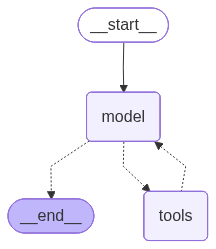

In [8]:
import os
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves retrieving a title,
    authors, publication_year, or research_focus. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results

# OpenRouter is OpenAI-compatible — point ChatOpenAI at it with the free nvidia model.
model = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
)

agent = create_agent(
    model=model,
    tools=[get_filter_context, search_documents],
    system_prompt="""You are a helpful health and fitness assistant.
                    For complex questions, break them down into simple sub-questions.
                    Always use search_documents to retrieve information — never answer from general knowledge.
                    Use get_filter_context before search_documents when the query involves specific metadata.
                    Always cite the source document in your answer.""",

    checkpointer=InMemorySaver(),
)

agent


## 4. Interactive Q&A

In [9]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

2026-06-02 23:17:30,388 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: vitamin D benefits...

Agent: Vitamin D supplementation offers several health and performance benefits, particularly when baseline vitamin D status is low. The evidence from the reviewed studies shows:

* **Increases circulating 25‑hydroxyvitamin D (25(OH)D)** – consistent across multiple trials (e.g., weekly 50 000 IU, daily 2000‑4000 IU, or intermittent high‑dose regimens)【03_Vitamin_D_Performance_2024.pdf】.  
* **Improves muscular strength** – significant gains in leg‑press, bench‑press, deadlift and vertical‑jump performance have been reported in athletes with low baseline levels after supplementation (20 000–40 000 IU/week or 50 000 IU weekly)【03_Vitamin_D_Performance_2024.pdf】.  
* **Enhances power and explosive performance** – improvements in sprint testing, explosive power, anaerobic peak power and isokinetic knee extension have been observed with do